#**Fashion-Intelligence-Engine**

**Loading the Dataset**

In [1]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d paramaggarwal/fashion-product-images-small -p /content --unzip



cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:33<00:00, 17.6MB/s]



**Connecting to DRIVE**

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**Importing Dependencies**

In [3]:
import os
import re
import io
import shutil
import tqdm


import numpy as np
import pandas as pd


import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor

!pip install -q faiss-cpu
import faiss

!pip install -q optuna
import optuna


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


from PIL import Image


import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


from google.colab import drive, files


from huggingface_hub import HfApi, login, hf_hub_download



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.2 MB/s eta 0:00:00


**Data Pre-Processing**

In [4]:
import pandas as pd

df = pd.read_csv("/content/styles.csv", on_bad_lines="skip")

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
df.shape

(44424, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [7]:
df.isnull().sum()


,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,15
season,21
year,1
usage,317
productDisplayName,7


In [8]:
df = df.dropna(subset=['productDisplayName'])
df = df.dropna(subset=['year'])

df['baseColour'] = df['baseColour'].fillna('unknown')
df['season'] = df['season'].fillna('unknown')
df['usage'] = df['usage'].fillna('unknown')

print("Cleaned shape:", df.shape)

Cleaned shape: (44416, 10)


In [9]:
import os

image_folder = '/content/images'


df['image_file'] = df['id'].astype(str) + '.jpg'


existing_images = set(os.listdir(image_folder))
before = len(df)
df = df[df['image_file'].isin(existing_images)]
after = len(df)
print(f"Rows before: {before}, after: {after}, dropped: {before - after}")


df_reset = df.reset_index(drop=True)

Rows before: 44416, after: 44411, dropped: 5


**Model**

In [11]:
from transformers import CLIPModel, CLIPProcessor
import torch

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Model loaded on:", device)

HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 2s [Retry 2/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 4s [Retry 3/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 8s [Retry 4/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 8s [Retry 5/5].


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json
Retrying in 2s [Retry 2/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json
Retrying in 4s [Retry 3/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json
Retrying in 8s [Retry 4/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json
Retrying in 1s [Retry 1/5].


...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded on: cuda


Actual description: ONLY Women Blue Jeans


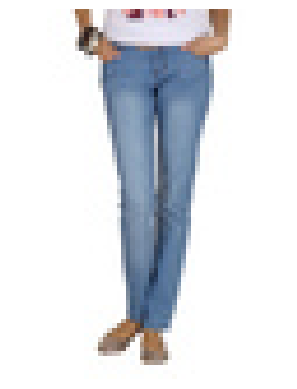

  0.0%  —  black shoes
  0.0%  —  a pair of running shoes
  0.0%  —  a red floral summer dress
100.0%  —  ONLY Women Blue Jeans
  0.0%  —  a men's formal wristwatch


In [12]:
import matplotlib.pyplot as plt
from PIL import Image

sample_row = df_reset.sample(1, random_state=42).iloc[0]
img_path = os.path.join(image_folder, sample_row['image_file'])
image = Image.open(img_path)

print("Actual description:", sample_row['productDisplayName'])
plt.imshow(image)
plt.axis('off')
plt.show()

candidate_texts = [
    "black shoes",
    "a pair of running shoes",
    "a red floral summer dress",
    sample_row['productDisplayName'],
    "a men's formal wristwatch"
]

inputs = processor(text=candidate_texts, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)

for text, prob in zip(candidate_texts, probs[0]):
    print(f"{prob.item()*100:5.1f}%  —  {text}")

**Image Embedding**

In [13]:
import os
import torch
import tqdm
import numpy as np
from PIL import Image

def load_images_for_batch(batch):

    images = []
    ids = []

    for _, row in batch.iterrows():
        image_path = os.path.join(image_folder, row["image_file"])

        try:
            img = Image.open(image_path).convert("RGB")
        except Exception:
            continue  # skip broken images

        images.append(img)
        ids.append(row["id"])

    return images, ids


def get_fingerprints(images):

    inputs = processor(images=images, return_tensors="pt").to(device)


    with torch.no_grad():
        fingerprints = model.get_image_features(**inputs)

    if not torch.is_tensor(fingerprints):
        if hasattr(fingerprints, "image_embeds"):
            fingerprints = fingerprints.image_embeds
        else:
            fingerprints = fingerprints.pooler_output

    fingerprints = fingerprints / fingerprints.norm(p=2, dim=-1, keepdim=True)

    return fingerprints






In [14]:
batch_size = 64
image_embeddings = []
valid_ids = []


In [15]:
import numpy as np
import pandas as pd

save_dir = '/content/drive/MyDrive/myntradataset/processed'

# This loads the already-computed results instead of recalculating them
image_embeddings = np.load(f'{save_dir}/image_embeddings.npy')
valid_ids = np.load(f'{save_dir}/valid_ids.npy', allow_pickle=True)
df_reset = pd.read_csv(f'{save_dir}/cleaned_styles.csv')

print("Embeddings shape:", image_embeddings.shape)
print("Number of IDs:", len(valid_ids))

Embeddings shape: (44411, 512)
Number of IDs: 44411


In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..

for start in tqdm.tqdm(range(0, len(df_reset), batch_size)):
    batch = df_reset.iloc[start:start + batch_size]

    images, ids = load_images_for_batch(batch)

    if len(images) == 0:
        continue

    fingerprints = get_fingerprints(images)

    image_embeddings.append(fingerprints.cpu().numpy())
    valid_ids.extend(ids)

image_embeddings = np.vstack(image_embeddings).astype("float32")
print("Shape of all embeddings:", image_embeddings.shape)

In [16]:


save_dir = '/content/drive/MyDrive/myntradataset/processed'
os.makedirs(save_dir, exist_ok=True)

np.save(f'{save_dir}/image_embeddings.npy', image_embeddings)
np.save(f'{save_dir}/valid_ids.npy', (valid_ids))
df_reset.to_csv(f'{save_dir}/cleaned_styles.csv', index=False)

print("All saved to:", save_dir)

All saved to: /content/drive/MyDrive/myntradataset/processed


In [17]:
!pip install -q faiss-cpu
import faiss

dimension = image_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(image_embeddings)

print("Total vectors in index:", index.ntotal)

Total vectors in index: 44411


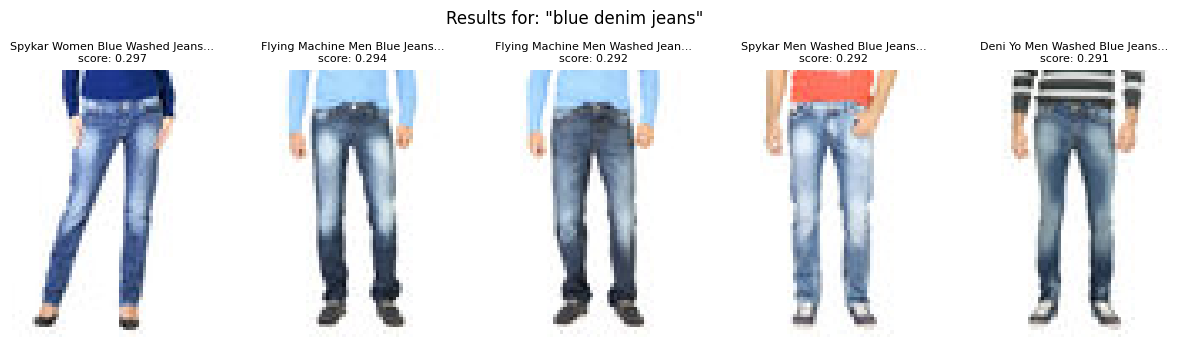

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

def search_by_text(query, top_k=5):

   inputs = processor(text=[query],return_tensors="pt", padding=True).to(device)
   with torch.no_grad():
       text_features = model.get_text_features(**inputs)

   if not torch.is_tensor(text_features):
      text_features = text_features.text_embeds if  hasattr(text_features,"text_embeds") else text_features.pooler_output

   text_features  =text_features / text_features.norm(dim=-1,keepdim=True)

   query_vector = text_features.cpu().numpy().astype("float32")

   similarities , indices = index.search(query_vector, top_k)

   results = []
   for rank,idx in enumerate(indices[0]):
       product_id = valid_ids[idx]
       score = similarities[0][rank]
       row = df_reset[df_reset["id"] == product_id].iloc[0]
       results.append((product_id,score,row))

   return results


def show_results(query, top_k=5):

    results = search_by_text(query, top_k)

    plt.figure(figsize=(15, 4))
    for i, (product_id, score, row) in enumerate(results):
        img_path = os.path.join(image_folder, f"{product_id}.jpg")

        try:
            img = Image.open(img_path)
        except Exception:
            print(f"⚠️ Couldn't find image for product {product_id}, skipping.")
            continue

        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{row['productDisplayName'][:30]}...\nscore: {score:.3f}", fontsize=8)

    plt.suptitle(f'Results for: "{query}"')
    plt.show()



show_results("blue denim jeans")

**Fine-Tuning**

In [19]:
# A natural-language caption for every product, using columns we already have
def make_caption(row):
    return f"{row['baseColour']} {row['productDisplayName']}, {row['usage']} wear for {row['season']}"

df_reset['caption'] = df_reset.apply(make_caption, axis=1)


df_reset[['productDisplayName', 'caption']].sample(5, random_state=1)

,productDisplayName,caption
23072,Enroute Women Casual Taupe Heels,"Taupe Enroute Women Casual Taupe Heels, Casual..."
40158,Myntra Women Cute Dog Yellow T-shirt,"Yellow Myntra Women Cute Dog Yellow T-shirt, C..."
42261,French Connection Women Brown Clutch,"Brown French Connection Women Brown Clutch, Ca..."
5688,Baggit Women Black Handbag,"Black Baggit Women Black Handbag, Casual wear ..."
31361,Shree Women Red & Black Kurta,"Red Shree Women Red & Black Kurta, Ethnic wear..."


In [20]:

id_to_caption = dict(zip(df_reset['id'], df_reset['caption']))

captions_for_training = [id_to_caption[x] for x in valid_ids]


for i in range(3):
    print(f"Embedding row {i} -> product {valid_ids[i]} -> caption: \"{captions_for_training[i]}\"")

Embedding row 0 -> product 15970 -> caption: "Navy Blue Turtle Check Men Navy Blue Shirt, Casual wear for Fall"
Embedding row 1 -> product 39386 -> caption: "Blue Peter England Men Party Blue Jeans, Casual wear for Summer"
Embedding row 2 -> product 59263 -> caption: "Silver Titan Women Silver Watch, Casual wear for Winter"


In [21]:
from sklearn.model_selection import train_test_split
import numpy as np


subset_size = 5000
subset_indices = np.random.choice(len(valid_ids), subset_size, replace=False)

subset_ids = [valid_ids[i] for i in subset_indices]
subset_captions = [captions_for_training[i] for i in subset_indices]

train_ids, test_ids, train_captions, test_captions = train_test_split(
    subset_ids, subset_captions, test_size=0.1, random_state=42
)

print("Training pairs:", len(train_ids))
print("Testing pairs:", len(test_ids))

Training pairs: 4500
Testing pairs: 500


Caption: Blue Jungle Book Boys Little help Blue T-shirt, Casual wear for Summer


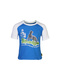

In [22]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class FashionDataset(Dataset):


    def __init__(self, ids, captions, image_folder):
        self.ids = ids
        self.captions = captions
        self.image_folder = image_folder

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):

        product_id = self.ids[i]
        caption = self.captions[i]

        img_path = os.path.join(self.image_folder, f"{product_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        return image, caption



train_dataset = FashionDataset(train_ids, train_captions, image_folder)
test_dataset = FashionDataset(test_ids, test_captions, image_folder)

sample_image, sample_caption = train_dataset[50]
print("Caption:", sample_caption)
sample_image

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..


from torch.utils.data import DataLoader

def collate_fn(batch):
  images = [item[0] for item in batch]
  captions = [item[1] for item in batch]


  inputs = processor(
           text = captions,
           images =images,
           return_tensors="pt",
           padding =True
  )
  return inputs


train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True,collate_fn=collate_fn)

test_loader = DataLoader(test_dataset, batch_size=32,shuffle=True,collate_fn=collate_fn)

batch = next(iter(train_loader))
print("Keys in a batch :" , batch.keys())
print("Image batch shape:", batch['pixel_values'].shape)
print("Text batch shape:",batch['input_ids'].shape)

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..



import torch
from torch.optim import AdamW

model.train()
optimizer = AdamW(model.parameters(), lr=5e-5)
total_loss = 0

for step, batch in enumerate(train_loader):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model(**batch, return_loss=True)
    loss = outputs.loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    if step % 10 == 0:
        print(f"Batch {step}/{len(train_loader)} - loss:{loss.item():.4f}")

avg_loss = total_loss / len(train_loader)
print(f"\nEpoch Done\nAverage Loss: {avg_loss:.4f}")

# SAVE IMMEDIATELY — same cell, no gap
save_path = '/content/drive/MyDrive/myntradataset/finetuned_clip'
model.save_pretrained(save_path)
processor.save_pretrained(save_path)
print("Saved to:", save_path)

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..


from transformers import CLIPModel, CLIPProcessor
import torch

load_path = '/content/drive/MyDrive/myntradataset/finetuned_clip'

finetuned_model = CLIPModel.from_pretrained(load_path)
finetuned_processor = CLIPProcessor.from_pretrained(load_path)

finetuned_model = finetuned_model.to(device)
finetuned_model.eval()  # switch OFF training mode, back to normal "just answer" mode

print("Loaded successfully. Model is on:", next(finetuned_model.parameters()).device)

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..



import matplotlib.pyplot as plt
from PIL import Image

# Pick a random real product to test with
sample_row = df_reset.sample(1, random_state=7).iloc[0]
img_path = os.path.join(image_folder, sample_row['image_file'])
image = Image.open(img_path).convert("RGB")

candidate_texts = [
    "black shoes",
    "a pair of running shoes",
    "a red floral summer dress",
    sample_row['productDisplayName'],
    "a men's formal wristwatch"
]

print("Actual description:", sample_row['productDisplayName'])
plt.imshow(image)
plt.axis('off')
plt.show()

# Run through the ORIGINAL pretrained model
inputs = processor(text=candidate_texts, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs = model(**inputs)
    probs_original = outputs.logits_per_image.softmax(dim=1)

# Run through the FINE-TUNED model
inputs_ft = finetuned_processor(text=candidate_texts, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs_ft = finetuned_model(**inputs_ft)
    probs_finetuned = outputs_ft.logits_per_image.softmax(dim=1)

print("--- ORIGINAL ---")
for text, prob in zip(candidate_texts, probs_original[0]):
    print(f"{prob.item()*100:.6f}%  —  {text}")

print("\n--- FINE-TUNED ---")
for text, prob in zip(candidate_texts, probs_finetuned[0]):
    print(f"{prob.item()*100:.6f}%  —  {text}")

**Stratified K-Fold Validation**

In [23]:
from sklearn.model_selection import StratifiedKFold
import numpy as np


categories = df_reset.set_index('id').loc[valid_ids]['articleType'].values

print("Numbr of Unique Categories :",len(set(categories)))

print("Example of Categories:",categories[:5])

Numbr of Unique Categories : 142
Example of Categories: ['Shirts' 'Jeans' 'Watches' 'Track Pants' 'Tshirts']


In [24]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

for fold_num,(train_idx,test_idx) in enumerate(skf.split(image_embeddings,categories)):
  print(f"Fold{fold_num}:train={len(train_idx)},test={len(test_idx)}")

Fold0:train=35528,test=8883
Fold1:train=35529,test=8882
Fold2:train=35529,test=8882
Fold3:train=35529,test=8882
Fold4:train=35529,test=8882


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [26]:
import torch

def evaluate_fold(test_idx, embeddings, valid_ids, captions_list, sample_size=200):

    if len(test_idx) > sample_size:
        test_idx = np.random.choice(test_idx, sample_size, replace=False)

    correct = 0
    total = 0

    group_size = 8
    for start in range(0, len(test_idx), group_size):
        group = test_idx[start:start + group_size]
        if len(group) < 2:
            continue


        group_ids = [valid_ids[i] for i in group]
        group_captions = [captions_list[i] for i in group]


        group_embeddings = embeddings[group]


        inputs = processor(text=group_captions, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            text_features = model.get_text_features(**inputs)
        if not torch.is_tensor(text_features):
            text_features = text_features.text_embeds if hasattr(text_features, "text_embeds") else text_features.pooler_output
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        text_features = text_features.cpu().numpy()


        similarity_matrix = group_embeddings @ text_features.T


        predictions = similarity_matrix.argmax(axis=1)
        correct += sum(predictions == np.arange(len(group)))
        total += len(group)

    accuracy = correct / total
    return accuracy

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..


fold_accuracies = []

for fold_num, (train_idx, test_idx) in enumerate(skf.split(image_embeddings, categories)):
    acc = evaluate_fold(test_idx, image_embeddings, valid_ids, captions_for_training)
    fold_accuracies.append(acc)
    print(f"Fold {fold_num}: accuracy = {acc:.3f}")

print(f"\nAverage accuracy across folds: {np.mean(fold_accuracies):.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 0: accuracy = 0.940
Fold 1: accuracy = 0.960
Fold 2: accuracy = 0.940
Fold 3: accuracy = 0.925
Fold 4: accuracy = 0.940

Average accuracy across folds: 0.941


**Optuna Model**

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..


# Install Optuna
!pip install -q optuna

import optuna
import torch
from torch.optim import AdamW
from transformers import CLIPModel, CLIPProcessor
import numpy as np

def objective(trial):
    # Step 1: Optuna picks values to try this round
    lr = trial.suggest_float("lr", 1e-6, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Step 2: Fresh model each trial (don't reuse a trained one)
    trial_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    trial_model.train()
    optimizer = AdamW(trial_model.parameters(), lr=lr)

    # Step 3: Rebuild DataLoader with this trial's batch size
    trial_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # Step 4: Train for a SHORT run (only ~30 batches, not full epoch) to save time
    total_loss = 0
    steps = 0
    for step, batch in enumerate(trial_loader):
        if step >= 30:   # cap steps per trial to keep it fast
            break
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = trial_model(**batch, return_loss=True)
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        steps += 1

    avg_loss = total_loss / steps
    return avg_loss   # Optuna will try to MINIMIZE this

# Step 5: Run the search — 8 trials, each trying different lr/batch_size
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=8)

print("Best params:", study.best_params)
print("Best loss:", study.best_value)

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..


# Step 6: Train ONE FINAL model using the best settings found, then save it
best_lr = study.best_params["lr"]
best_batch_size = study.best_params["batch_size"]

final_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
final_model.train()
optimizer = AdamW(final_model.parameters(), lr=best_lr)
final_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True, collate_fn=collate_fn)

total_loss = 0
for step, batch in enumerate(final_loader):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = final_model(**batch, return_loss=True)
    loss = outputs.loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    if step % 10 == 0:
        print(f"Batch {step}/{len(final_loader)} - loss:{loss.item():.4f}")

print(f"\nFinal avg loss: {total_loss/len(final_loader):.4f}")

# SAVE IMMEDIATELY — same cell, no gap, so a disconnect can't lose it
save_path = '/content/drive/MyDrive/myntradataset/optuna_tuned_clip'
final_model.save_pretrained(save_path)
processor.save_pretrained(save_path)
print("Saved to:", save_path)

In [27]:
#  RUN THIS — reloads your saved, Optuna-tuned model
from transformers import CLIPModel, CLIPProcessor

optuna_model = CLIPModel.from_pretrained('/content/drive/MyDrive/myntradataset/optuna_tuned_clip').to(device)
optuna_processor = CLIPProcessor.from_pretrained('/content/drive/MyDrive/myntradataset/optuna_tuned_clip')
optuna_model.eval()

print("Optuna-tuned model loaded and ready.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Optuna-tuned model loaded and ready.


## Gives you comparison between original model and optuna model

In [33]:
sample_row = df_reset.sample(1, random_state=27).iloc[0]
img_path = os.path.join(image_folder, sample_row['image_file'])
image = Image.open(img_path).convert("RGB")

candidate_texts = [
    "black shoes",
    "a pair of running shoes",
    "a red floral summer dress",
    sample_row['productDisplayName'],
    "a men's formal wristwatch"
]

# ORIGINAL model
inputs = processor(text=candidate_texts, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs = model(**inputs)
    probs_original = outputs.logits_per_image.softmax(dim=1)

# OPTUNA-TUNED model
inputs_opt = optuna_processor(text=candidate_texts, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    outputs_opt = optuna_model(**inputs_opt)
    probs_optuna = outputs_opt.logits_per_image.softmax(dim=1)

print("Actual description:", sample_row['productDisplayName'])
print("\n--- ORIGINAL ---")
for text, prob in zip(candidate_texts, probs_original[0]):
    print(f"{prob.item()*100:.4f}%  —  {text}")

print("\n--- OPTUNA-TUNED ---")
for text, prob in zip(candidate_texts, probs_optuna[0]):
    print(f"{prob.item()*100:.4f}%  —  {text}")

Actual description: Nike Men Black Air Dictate Sports Shoes

--- ORIGINAL ---
0.0377%  —  black shoes
1.0398%  —  a pair of running shoes
0.0000%  —  a red floral summer dress
98.9225%  —  Nike Men Black Air Dictate Sports Shoes
0.0000%  —  a men's formal wristwatch

--- OPTUNA-TUNED ---
0.0251%  —  black shoes
0.3344%  —  a pair of running shoes
0.0000%  —  a red floral summer dress
99.6405%  —  Nike Men Black Air Dictate Sports Shoes
0.0000%  —  a men's formal wristwatch


## k straiaght fold on optuna model

In [48]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..

fold_accuracies_optuna = []
for fold_num, (train_idx, test_idx) in enumerate(skf.split(image_embeddings, categories)):
    acc = evaluate_fold(test_idx, image_embeddings, valid_ids, captions_for_training)
    fold_accuracies_optuna.append(acc)
    print(f"Fold {fold_num}: accuracy = {acc:.3f}")

print(f"\nOptuna model average accuracy: {np.mean(fold_accuracies_optuna):.3f}")
print(f"Original model average accuracy: 0.941")



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 0: accuracy = 0.935
Fold 1: accuracy = 0.965
Fold 2: accuracy = 0.955
Fold 3: accuracy = 0.980
Fold 4: accuracy = 0.970

Optuna model average accuracy: 0.961
Original model average accuracy: 0.941


## loading Embeddings in optuna model

In [ ]:
# ⚠️ DON'T RE-RUN — already completed & saved to Drive..


model = optuna_model
processor = optuna_processor
model.eval()

batch_size = 64
new_image_embeddings = []
new_valid_ids = []

for start in tqdm.tqdm(range(0, len(df_reset), batch_size)):
    batch = df_reset.iloc[start:start + batch_size]
    images, ids = load_images_for_batch(batch)
    if len(images) == 0:
        continue
    fingerprints = get_fingerprints(images)
    new_image_embeddings.append(fingerprints.cpu().numpy())
    new_valid_ids.extend(ids)

new_image_embeddings = np.vstack(new_image_embeddings).astype("float32")
print("Shape:", new_image_embeddings.shape)

# Save these as a SEPARATE file — don't overwrite your original embeddings
save_dir = '/content/drive/MyDrive/myntradataset/processed'
np.save(f'{save_dir}/image_embeddings_optuna.npy', new_image_embeddings)
np.save(f'{save_dir}/valid_ids_optuna.npy', new_valid_ids)


In [29]:
import numpy as np

save_dir = "/content/drive/MyDrive/myntradataset/processed"

new_image_embeddings = np.load(f"{save_dir}/image_embeddings_optuna.npy")
new_valid_ids = np.load(f"{save_dir}/valid_ids_optuna.npy", allow_pickle=True)

print(new_image_embeddings.shape)
print(len(new_valid_ids))

(44411, 512)
44411


**Synthtic PRICE column**

In [30]:
import numpy as np

category_price_ranges = {
    'Watches': (1500, 8000), 'Jackets': (1200, 4000), 'Handbags': (800, 3000),
    'Sarees': (600, 5000), 'Sunglasses': (400, 2500), 'Shoes': (700, 3500),
    'Casual Shoes': (700, 3500), 'Formal Shoes': (1000, 4000),
    'Tshirts': (300, 1200), 'Shirts': (500, 2000), 'Jeans': (700, 2500),
    'Dresses': (600, 3000), 'Kurtas': (500, 2500), 'Sandals': (300, 1500),
    'Heels': (600, 3000), 'Flip Flops': (150, 600), 'Belts': (250, 1200),
    'Wallets': (300, 1500), 'Backpacks': (600, 3000),
}
default_range = (300, 2000)
np.random.seed(42)

def generate_price(category):
    low, high = category_price_ranges.get(category, default_range)
    return np.random.randint(low, high)

df_reset['price'] = df_reset['articleType'].apply(generate_price)
print("⚠️ NOTE: 'price' column is SYNTHETIC — for demo purposes only.")
print(df_reset[['articleType', 'price']].sample(3, random_state=78))

⚠️ NOTE: 'price' column is SYNTHETIC — for demo purposes only.
      articleType  price
15651        Tops    516
42590     Tshirts    670
41853      Briefs   1119


In [31]:
# Save the price-updated dataframe back to Drive as cleaned_styles.csv
save_dir = '/content/drive/MyDrive/myntradataset/processed'
df_reset.to_csv(f'{save_dir}/cleaned_styles.csv', index=False)

print(" Saved with price column.")
print("Columns now:", df_reset.columns.tolist())
print(df_reset[['articleType', 'price']].sample(3))

 Saved with price column.
Columns now: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_file', 'price', 'caption']
      articleType  price
26842         Bra   1825
35888     Wallets    572
4922      Tshirts    440


**Query Parsing**

In [34]:
import re


known_colors = df_reset['baseColour'].str.lower().unique().tolist()
known_categories = df_reset['articleType'].str.lower().unique().tolist()

def parse_query(query):
    q = query.lower()
    filters = {}

    price_match = re.search(r'(?:under|below|less than)\s*\$?(\d+)', q)
    if price_match:
        filters['max_price'] = int(price_match.group(1))

    for color in known_colors:
        if color in q:
            filters['color'] = color
            break


    for cat in known_categories:
        cat_singular = cat.rstrip('s')
        if cat in q or cat_singular in q:
            filters['category'] = cat
            break

    if 'women' in q or "women's" in q:
       filters['gender'] = 'Women'
    elif 'men' in q.split() or "men's" in q:
       filters['gender'] = 'Men'

    return filters

print(parse_query("blue shirt for men under 700"))
print(parse_query("striped shirt for men"))

{'max_price': 700, 'color': 'blue', 'category': 'shirts', 'gender': 'Men'}
{'category': 'shirts', 'gender': 'Men'}


In [35]:
def apply_filters(df, filters):

    filtered = df.copy()

    if 'max_price' in filters:
        filtered = filtered[filtered['price'] <= filters['max_price']]

    if 'color' in filters:
        filtered = filtered[filtered['baseColour'].str.lower() == filters['color']]

    if 'category' in filters:
        filtered = filtered[filtered['articleType'].str.lower() == filters['category']]

    if 'gender' in filters:
        filtered = filtered[filtered['gender'] == filters['gender']]

    return filtered

In [36]:
def smart_search(query, top_k=5):

    filters = parse_query(query)
    filtered_df = apply_filters(df_reset, filters)

    print(f"Detected filters: {filters}")
    print(f"Matching products before search: {len(filtered_df)}")


    if len(filtered_df) == 0:
        print("⚠️ No exact matches for your filters — showing closest results instead.")
        filtered_df = df_reset


    allowed_ids = set(filtered_df['id'])
    id_to_row_index = {pid: i for i, pid in enumerate(valid_ids) if pid in allowed_ids}

    if len(id_to_row_index) == 0:
        print("No embeddings available for filtered items.")
        return


    allowed_indices = list(id_to_row_index.values())
    mini_embeddings = image_embeddings[allowed_indices]


    inputs = processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
    if not torch.is_tensor(text_features):
        text_features = text_features.text_embeds if hasattr(text_features, "text_embeds") else text_features.pooler_output
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    query_vector = text_features.cpu().numpy().astype("float32")


    similarities = (mini_embeddings @ query_vector.T).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]

    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(top_indices):
        row_index = allowed_indices[idx]
        product_id = valid_ids[row_index]
        score = similarities[idx]
        row = df_reset[df_reset["id"] == product_id].iloc[0]

        img_path = os.path.join(image_folder, row['image_file'])
        try:
            img = Image.open(img_path)
        except Exception:
            continue

        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{row['productDisplayName'][:25]}...\n₹{row['price']} | score:{score:.3f}", fontsize=7)

    plt.suptitle(f'Results for: "{query}"')
    plt.show()

Detected filters: {'max_price': 2000, 'category': 'formal shoes', 'gender': 'Men'}
Matching products before search: 215


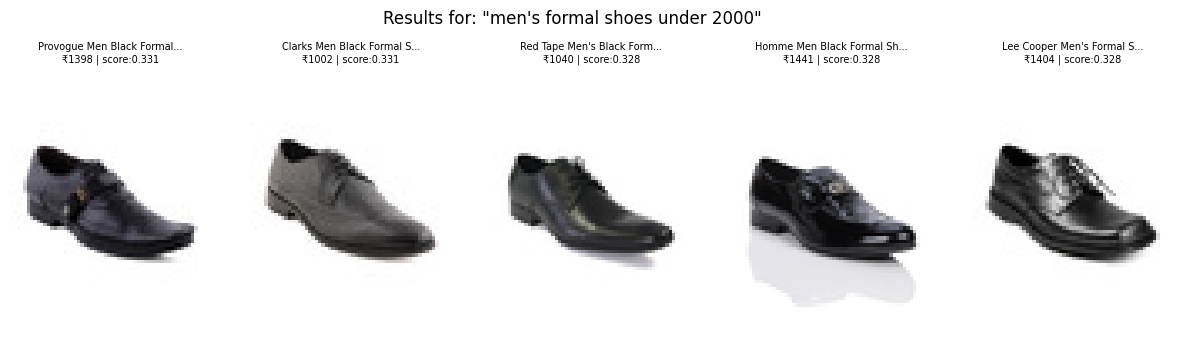

Detected filters: {'max_price': 700, 'color': 'blue', 'category': 'shirts', 'gender': 'Men'}
Matching products before search: 86


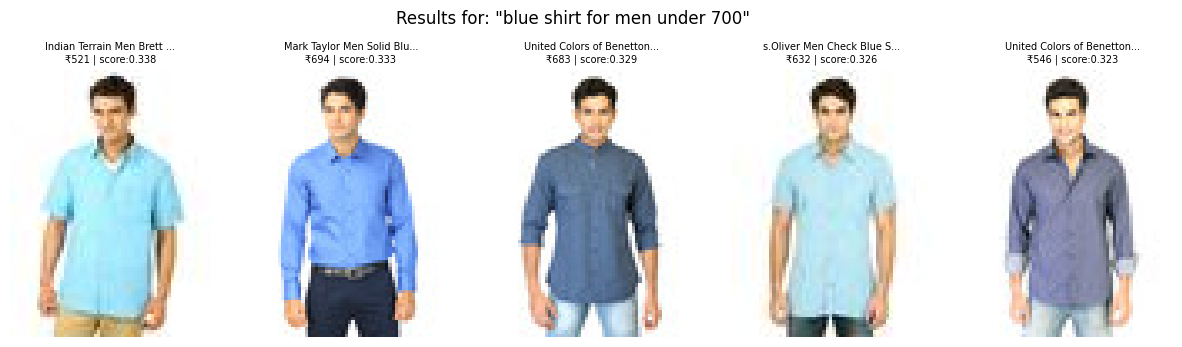

Detected filters: {'max_price': 500, 'color': 'blue', 'category': 'jeans'}
Matching products before search: 0
⚠️ No exact matches for your filters — showing closest results instead.


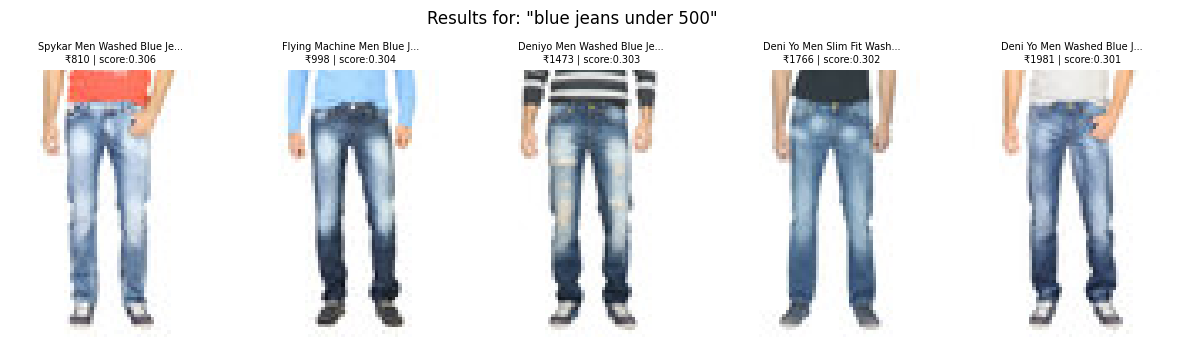

In [37]:
smart_search("men's formal shoes under 2000")
smart_search("blue shirt for men under 700")
smart_search("blue jeans under 500")

**Explainability**





In [38]:
def explain_match(query, row, filters):
    reasons = []
    q = query.lower()

    try:
        if isinstance(row['baseColour'], str) and row['baseColour'].lower() in q:
            reasons.append(f"color: {row['baseColour']}")

        if isinstance(row['articleType'], str) and row['articleType'].lower() in q:
            reasons.append(f"category: {row['articleType']}")

        if 'gender' in filters and row['gender'] == filters['gender']:
            reasons.append(f"for: {row['gender']}")

        if isinstance(row['usage'], str) and row['usage'].lower() in q:
            reasons.append(f"occasion: {row['usage']}")

        if isinstance(row['season'], str) and row['season'].lower() in q:
            reasons.append(f"season: {row['season']}")

        if 'max_price' in filters and row['price'] <= filters['max_price']:
            reasons.append(f"within budget (₹{row['price']})")

    except Exception as e:
        reasons.append(f"(explanation error: {e})")

    if not reasons:
        reasons.append("matched by overall visual/text similarity (CLIP)")

    return reasons

In [39]:
def smart_search_explained(query, top_k=5):

    filters = parse_query(query)
    filtered_df = apply_filters(df_reset, filters)

    print(f"Detected filters: {filters}")
    print(f"Matching products before search: {len(filtered_df)}")

    if len(filtered_df) == 0:
        print("⚠️ No exact matches for your filters — showing closest results instead.")
        filtered_df = df_reset

    allowed_ids = set(filtered_df['id'])
    id_to_row_index = {pid: i for i, pid in enumerate(valid_ids) if pid in allowed_ids}

    if len(id_to_row_index) == 0:
        print("No embeddings available for filtered items.")
        return

    allowed_indices = list(id_to_row_index.values())
    mini_embeddings = image_embeddings[allowed_indices]

    inputs = processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
    if not torch.is_tensor(text_features):
        text_features = text_features.text_embeds if hasattr(text_features, "text_embeds") else text_features.pooler_output
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    query_vector = text_features.cpu().numpy().astype("float32")

    similarities = (mini_embeddings @ query_vector.T).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]

    plt.figure(figsize=(18, 5))
    for i, idx in enumerate(top_indices):
        row_index = allowed_indices[idx]
        product_id = valid_ids[row_index]
        score = similarities[idx]
        row = df_reset[df_reset["id"] == product_id].iloc[0]


        reasons = explain_match(query, row, filters)

        img_path = os.path.join(image_folder, row['image_file'])
        try:
            img = Image.open(img_path)
        except Exception:
            continue

        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.axis('off')


        title = f"{row['productDisplayName'][:20]}...\n₹{row['price']} | score:{score:.3f}"
        plt.title(title, fontsize=7)


        print(f"\nResult {i+1}: {row['productDisplayName']}")
        print("  Why it matched:", ", ".join(reasons))

    plt.suptitle(f'Results for: "{query}"')
    plt.show()

In [40]:
image_embeddings = new_image_embeddings
valid_ids = new_valid_ids
index.reset()
index.add(image_embeddings)

Detected filters: {'max_price': 1500, 'color': 'white', 'category': 'shirts', 'gender': 'Men'}
Matching products before search: 315

Result 1: Peter England Men Solid White Shirt
  Why it matched: color: White, for: Men, occasion: Formal, within budget (₹662)

Result 2: John Miller Men White Shirt
  Why it matched: color: White, for: Men, occasion: Formal, within budget (₹1391)

Result 3: Arrow Men White Striped Shirt
  Why it matched: color: White, for: Men, occasion: Formal, within budget (₹765)

Result 4: United Colors of Benetton Men Self Stripes White Shirt
  Why it matched: color: White, for: Men, within budget (₹878)

Result 5: United Colors of Benetton Men Solid White Shirt
  Why it matched: color: White, for: Men, within budget (₹511)


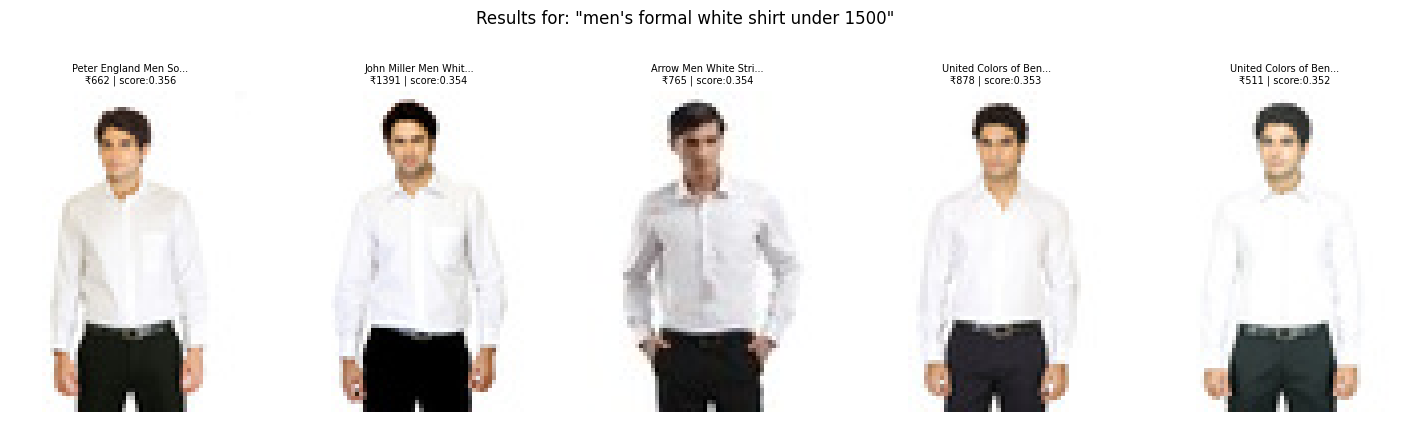

Detected filters: {'color': 'black', 'category': 'jackets', 'gender': 'Women'}
Matching products before search: 16

Result 1: Nike Women Sptcas Black Jacket
  Why it matched: color: Black, for: Women

Result 2: United Colors of Benetton Women Solid Black Jacket
  Why it matched: color: Black, for: Women

Result 3: Puma Women Solid Black Jackets
  Why it matched: color: Black, for: Women

Result 4: United Colors of Benetton Women Solid Black Jacket
  Why it matched: color: Black, for: Women

Result 5: C Vox Women Solid 1351 Black Jacket
  Why it matched: color: Black, for: Women


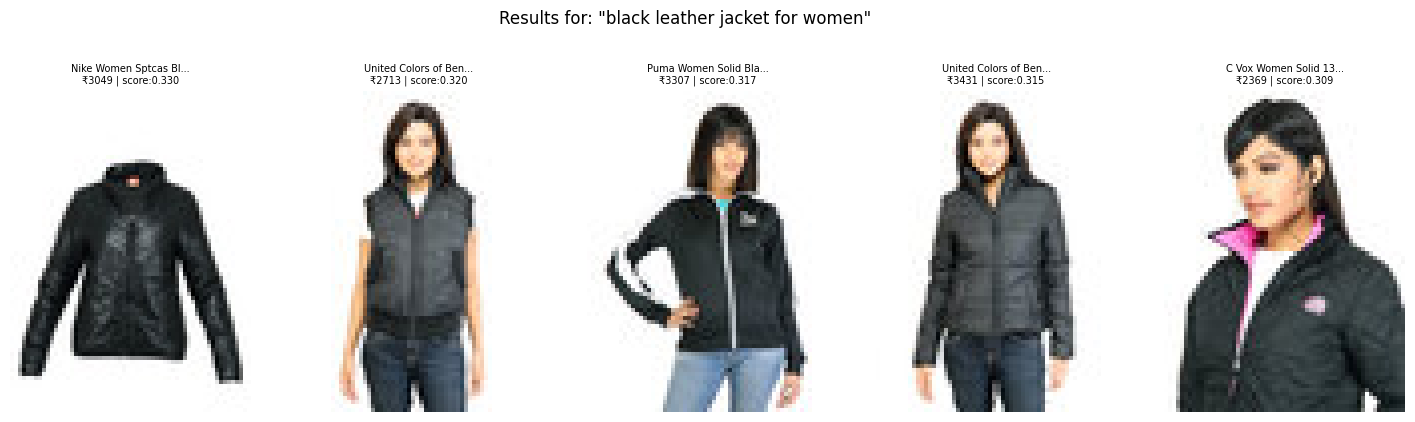

Detected filters: {'category': 'shirts', 'gender': 'Men'}
Matching products before search: 2842

Result 1: Probase Men Stripes Pink Shirts
  Why it matched: category: Shirts, for: Men

Result 2: Wills Lifestyle Men Stripes Grey Shirt
  Why it matched: category: Shirts, for: Men

Result 3: Indigo Nation Men Checks Red Shirts
  Why it matched: category: Shirts, for: Men

Result 4: Indigo Nation Men Checks Red Shirts
  Why it matched: category: Shirts, for: Men

Result 5: Spykar Men Ranger Black N Red Stripe White Shirts
  Why it matched: category: Shirts, for: Men


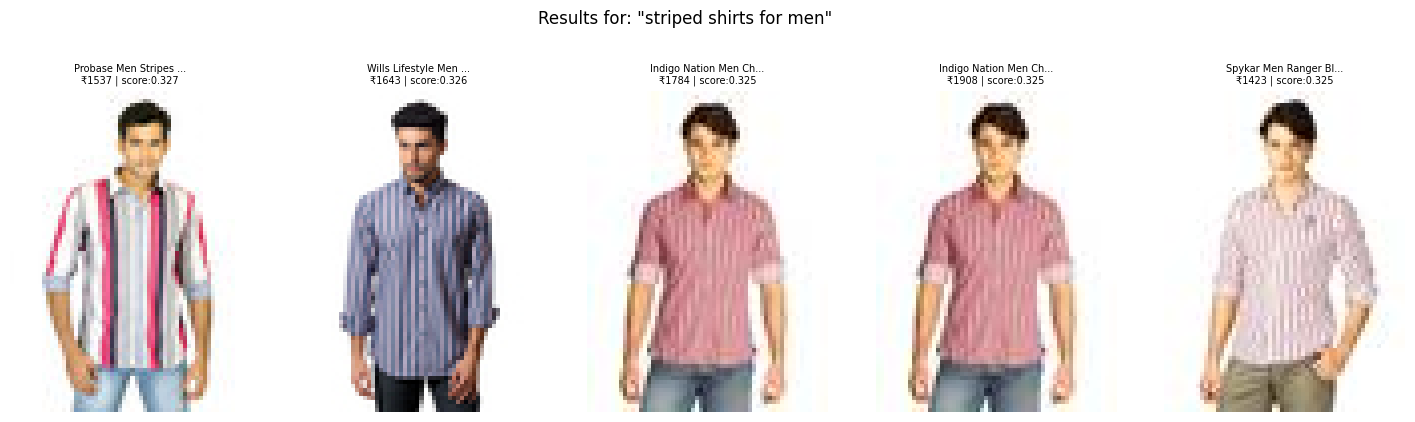

Detected filters: {'max_price': 1000, 'color': 'red', 'category': 'kurtas'}
Matching products before search: 29

Result 1: Fabindia Women Printed Red Kurta
  Why it matched: color: Red, within budget (₹717)

Result 2: Aurelia Women Red Kurta
  Why it matched: color: Red, within budget (₹913)

Result 3: Aurelia Women Solid Red Kurta
  Why it matched: color: Red, within budget (₹542)

Result 4: Vishudh Women Printed Rust Red Kurta
  Why it matched: color: Red, within budget (₹963)

Result 5: W Women Thread Work Red Kurta
  Why it matched: color: Red, within budget (₹565)


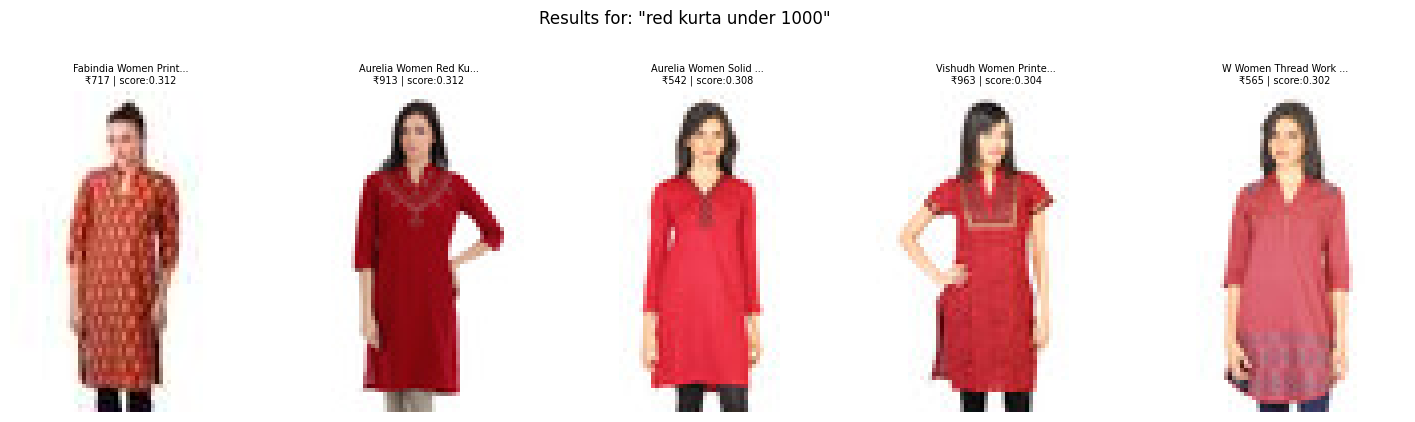

Detected filters: {'gender': 'Women'}
Matching products before search: 18627

Result 1: Shree Women Yellow & Brown Printed Salwar Suit with Dupatta
  Why it matched: for: Women, occasion: Ethnic

Result 2: FNF Red & Gold Collection for Wedding Sari
  Why it matched: for: Women, occasion: Ethnic

Result 3: Satya Paul Cream and Brown Saree
  Why it matched: for: Women, occasion: Ethnic

Result 4: FNF Red Bridal Collection Lehenga Choli
  Why it matched: for: Women, occasion: Ethnic

Result 5: FNF Maroon & Cream Wedding Collection Sari
  Why it matched: for: Women, occasion: Ethnic


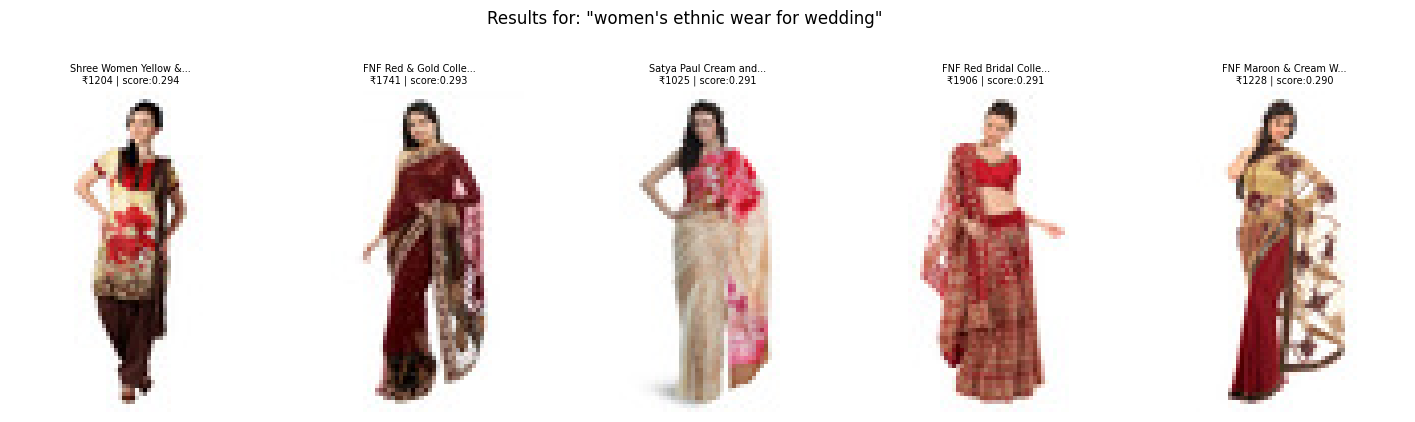

Detected filters: {'max_price': 700, 'color': 'blue', 'category': 'shirts', 'gender': 'Men'}
Matching products before search: 86

Result 1: Indian Terrain Men Brett Blue Shirts
  Why it matched: color: Blue, for: Men, occasion: Casual, within budget (₹521)

Result 2: United Colors of Benetton Men Check Blue Shirt
  Why it matched: color: Blue, for: Men, occasion: Casual, within budget (₹582)

Result 3: Fabindia Men Striped Blue Shirt
  Why it matched: color: Blue, for: Men, within budget (₹622)

Result 4: United Colors of Benetton Men Solid Blue Shirts
  Why it matched: color: Blue, for: Men, occasion: Casual, within budget (₹546)

Result 5: Scullers Men Check Blue Shirts
  Why it matched: color: Blue, for: Men, occasion: Casual, within budget (₹564)


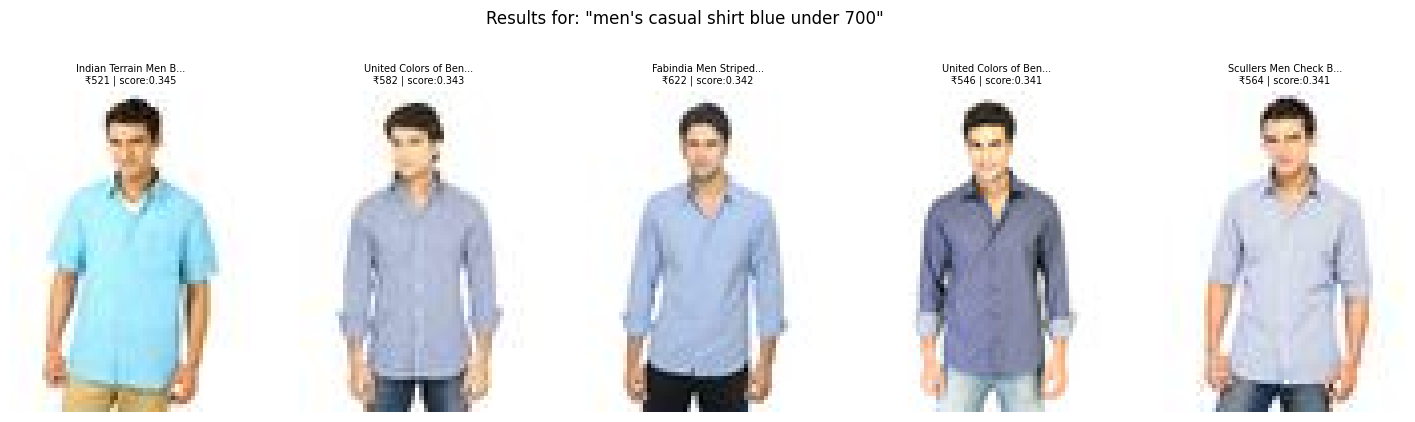

In [41]:
smart_search_explained("men's formal white shirt under 1500")
smart_search_explained("black leather jacket for women")
smart_search_explained("striped shirts for men")
smart_search_explained("red kurta under 1000")
smart_search_explained("women's ethnic wear for wedding")
smart_search_explained("men's casual shirt blue under 700")

**Image-based refinement**

In [43]:
from google.colab import files

uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]
print("Uploaded:",uploaded_filename)

Saving 1554.jpg to 1554.jpg
Uploaded: 1554.jpg


In [45]:
def refine_search(image_path, refine_text, top_k=5, image_weight=0.5):

    # Step 1: Turn the uploaded image into a fingerprint
    ref_image = Image.open(image_path).convert("RGB")
    img_inputs = processor(images=ref_image, return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = model.get_image_features(**img_inputs)
    if not torch.is_tensor(image_features):
        image_features = image_features.image_embeds if hasattr(image_features, "image_embeds") else image_features.pooler_output
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Step 2: Turn the refinement text into a fingerprint (e.g. "but in blue")
    text_inputs = processor(text=[refine_text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)
    if not torch.is_tensor(text_features):
        text_features = text_features.text_embeds if hasattr(text_features, "text_embeds") else text_features.pooler_output
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Step 3: Blend the two fingerprints into ONE combined fingerprint
    combined = image_weight * image_features + (1 - image_weight) * text_features
    combined = combined / combined.norm(dim=-1, keepdim=True)   # re-normalize after blending
    query_vector = combined.cpu().numpy().astype("float32")

    # Step 4: Search FAISS/embeddings using this blended fingerprint
    similarities = (image_embeddings @ query_vector.T).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]

    # Step 5: Show the uploaded image + the results side by side
    plt.figure(figsize=(15, 4))

    plt.subplot(1, top_k + 1, 1)
    plt.imshow(ref_image)
    plt.axis('off')
    plt.title("Your upload", fontsize=9)

    for i, idx in enumerate(top_indices):
        product_id = valid_ids[idx]
        score = similarities[idx]
        row = df_reset[df_reset["id"] == product_id].iloc[0]

        img_path = os.path.join(image_folder, row['image_file'])
        try:
            img = Image.open(img_path)
        except Exception:
            continue

        plt.subplot(1, top_k + 1, i + 2)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{row['productDisplayName'][:25]}...\n₹{row['price']} | score:{score:.3f}", fontsize=7)

    plt.suptitle(f'Refined with: "{refine_text}" (image_weight={image_weight})')
    plt.show()

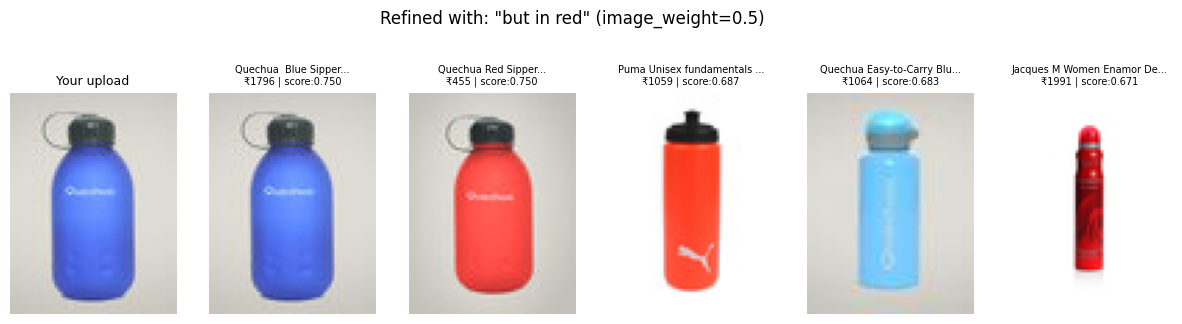

In [47]:
refine_search(uploaded_filename, "but in red", top_k=5)

**Deployment**

In [ ]:
# ⚠️ DON'T RE-RUN
from huggingface_hub import login
login()

Creating copies of images in subfolders as Hugging-Face doesnt take too many files at a time

In [50]:
# ⚠️ DON'T RE-RUN
import os
import shutil

source_folder = "/content/images"
organized_folder = "/content/images_organized"
os.makedirs(organized_folder, exist_ok=True)

chunk_size = 5000
files = os.listdir(source_folder)

for f in files:
    try:
        product_id = int(f.split('.')[0])
    except ValueError:
        continue
    bucket = product_id // chunk_size  # groups IDs into buckets of 5000
    bucket_folder = os.path.join(organized_folder, f"bucket_{bucket}")
    os.makedirs(bucket_folder, exist_ok=True)
    shutil.copy(os.path.join(source_folder, f), os.path.join(bucket_folder, f))

print("✅ Organized into subfolders.")

print("Buckets created:", len(os.listdir(organized_folder)))

✅ Organized into subfolders.
Buckets created: 13


**Uploads your subfolders to Hugging-Face**

In [52]:
# ⚠️ DON'T RE-RUN
from huggingface_hub import HfApi

api = HfApi()

api.upload_folder(
    folder_path="/content/images_organized",
    path_in_repo="images",
    repo_id="sohaillansarii/fashion-search",
    repo_type="dataset",
)

print("Images uploaded to Hugging Face.")

✅ Images uploaded to Hugging Face.


**Business Impact Comparison**

In [48]:

original_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
original_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
original_model.eval()


optuna_model = CLIPModel.from_pretrained('/content/drive/MyDrive/myntradataset/optuna_tuned_clip').to(device)
optuna_processor = CLIPProcessor.from_pretrained('/content/drive/MyDrive/myntradataset/optuna_tuned_clip')
optuna_model.eval()


save_dir = '/content/drive/MyDrive/myntradataset/processed'
original_embeddings = np.load(f'{save_dir}/image_embeddings.npy')
optuna_embeddings = np.load(f'{save_dir}/image_embeddings_optuna.npy')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [69]:
import pandas as pd

comparison_data = {
    "Metric": [
        "K-Fold Avg Accuracy (image-caption matching)",
        "Training time invested",
        "Embedding generation time (44,411 images)",
    ],
    "Original CLIP": ["0.941", "0 (no training)", "~4 min"],
    "Optuna-Tuned CLIP": ["0.960–0.963", "~few min training + 8 search trials", "~4 min (re-embedded)"],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                                      Metric   Original CLIP                   Optuna-Tuned CLIP
K-Fold Avg Accuracy (image-caption matching)           0.941                         0.960–0.963
                      Training time invested 0 (no training) ~few min training + 8 search trials
   Embedding generation time (44,411 images)          ~4 min                ~4 min (re-embedded)


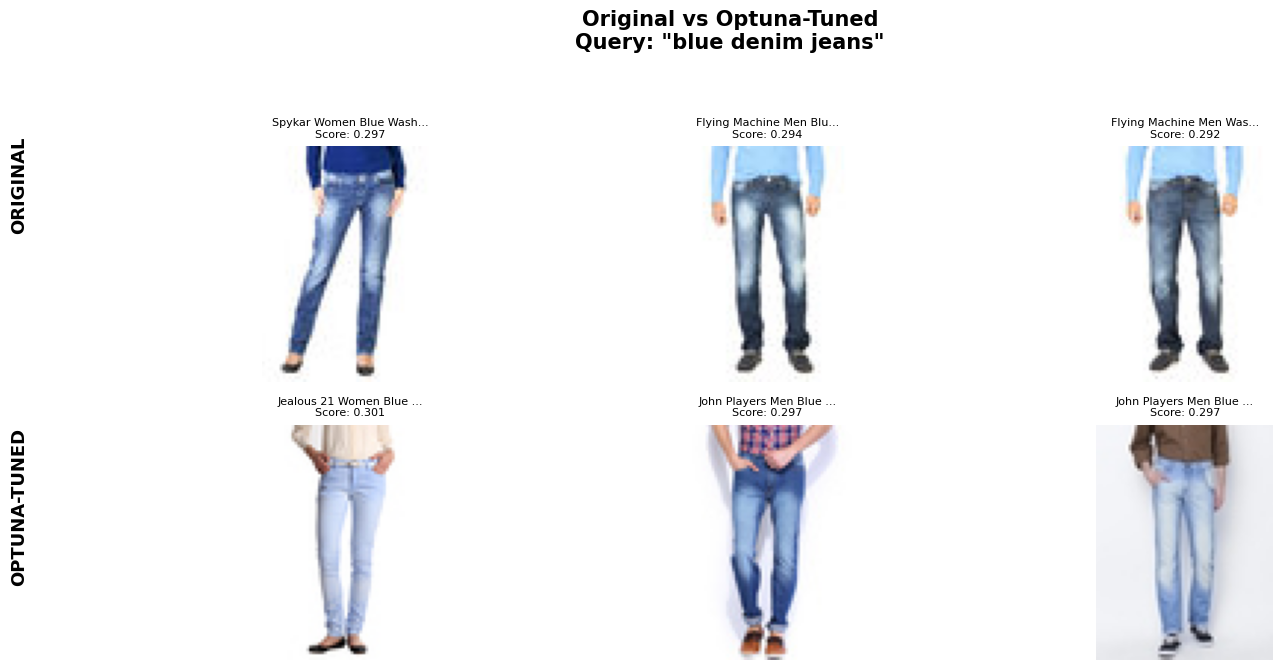

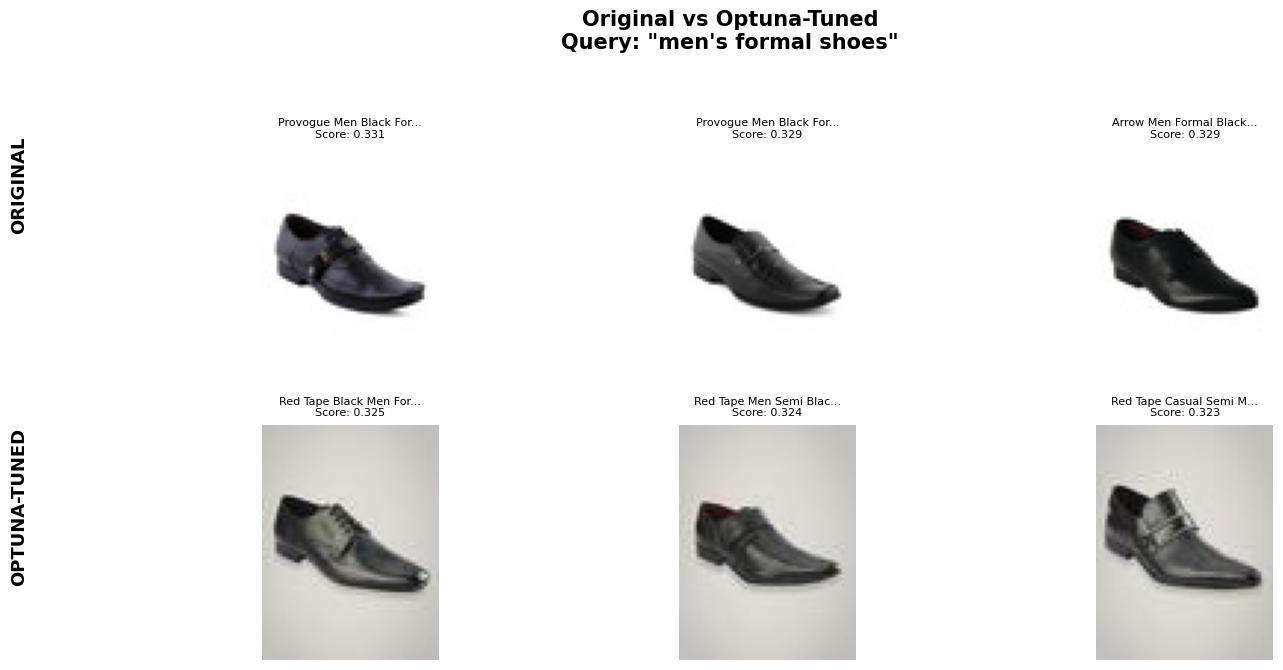

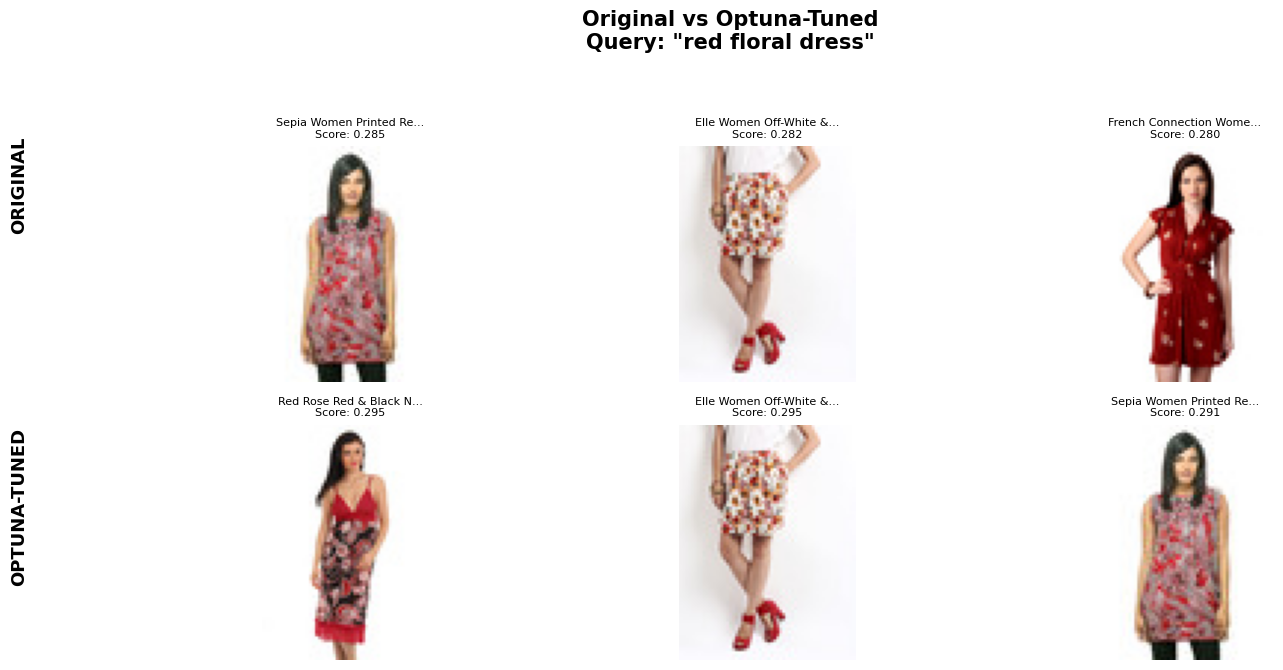

In [67]:
def compare_models_visual(query, top_k=3):
    """
    Runs the SAME query through both models and shows results side by side.
    """
    fig, axes = plt.subplots(2, top_k, figsize=(15, 7))

    # Row labels on the left
    fig.text(0.02, 0.73, "ORIGINAL", fontsize=13, fontweight="bold",
             rotation=90, va="center")
    fig.text(0.02, 0.27, "OPTUNA-TUNED", fontsize=13, fontweight="bold",
             rotation=90, va="center")

    for row_idx, (label, mdl, proc, embs) in enumerate([
        ("ORIGINAL", original_model, original_processor, original_embeddings),
        ("OPTUNA-TUNED", optuna_model, optuna_processor, optuna_embeddings),
    ]):

        # Encode query
        inputs = proc(text=[query], return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            text_features = mdl.get_text_features(**inputs)

        if not torch.is_tensor(text_features):
            text_features = (
                text_features.text_embeds
                if hasattr(text_features, "text_embeds")
                else text_features.pooler_output
            )

        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        query_vector = text_features.cpu().numpy().astype("float32")

        # Similarities
        similarities = (embs @ query_vector.T).flatten()
        top_indices = similarities.argsort()[::-1][:top_k]

        for col_idx, idx in enumerate(top_indices):
            product_id = valid_ids[idx]
            score = similarities[idx]
            row = df_reset[df_reset["id"] == product_id].iloc[0]
            img_path = os.path.join(image_folder, row["image_file"])

            try:
                img = Image.open(img_path).convert("RGB")
                axes[row_idx, col_idx].imshow(img)
            except Exception:
                axes[row_idx, col_idx].text(
                    0.5, 0.5, "Image\nNot Found",
                    ha="center", va="center", fontsize=10
                )

            axes[row_idx, col_idx].axis("off")
            axes[row_idx, col_idx].set_title(
                f"{row['productDisplayName'][:22]}...\nScore: {score:.3f}",
                fontsize=8
            )

    plt.suptitle(f'Original vs Optuna-Tuned\nQuery: "{query}"',
                 fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0.05, 0.03, 1, 0.93])
    plt.show()


# Run on a few real test queries
compare_models_visual("blue denim jeans")
compare_models_visual("men's formal shoes")
compare_models_visual("red floral dress")

**Model Accuracy Details**




In [58]:
def evaluate_top5(test_idx, sample_size=1000):
    if len(test_idx) > sample_size:
        test_idx = np.random.choice(test_idx, sample_size, replace=False)

    correct_top1, correct_top5, total = 0, 0, 0
    group_size = 10

    for start in range(0, len(test_idx), group_size):
        group = test_idx[start:start + group_size]
        if len(group) < 2:
            continue

        group_captions = [captions_for_training[i] for i in group]
        group_embeddings = image_embeddings[group]

        inputs = processor(text=group_captions, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            text_features = model.get_text_features(**inputs)
        if not torch.is_tensor(text_features):
            text_features = text_features.text_embeds if hasattr(text_features, "text_embeds") else text_features.pooler_output
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        text_features = text_features.cpu().numpy()

        similarity_matrix = group_embeddings @ text_features.T
        top5_preds = np.argsort(similarity_matrix, axis=1)[:, ::-1][:, :5]

        for i in range(len(group)):
            if top5_preds[i, 0] == i:
                correct_top1 += 1
            if i in top5_preds[i]:
                correct_top5 += 1
            total += 1

    return correct_top1 / total, correct_top5 / total

top1, top5 = evaluate_top5(list(range(len(valid_ids))))
print(f"Top-1 Accuracy: {top1:.3f}")
print(f"Top-5 Accuracy: {top5:.3f}")

Top-1 Accuracy: 0.949
Top-5 Accuracy: 0.999


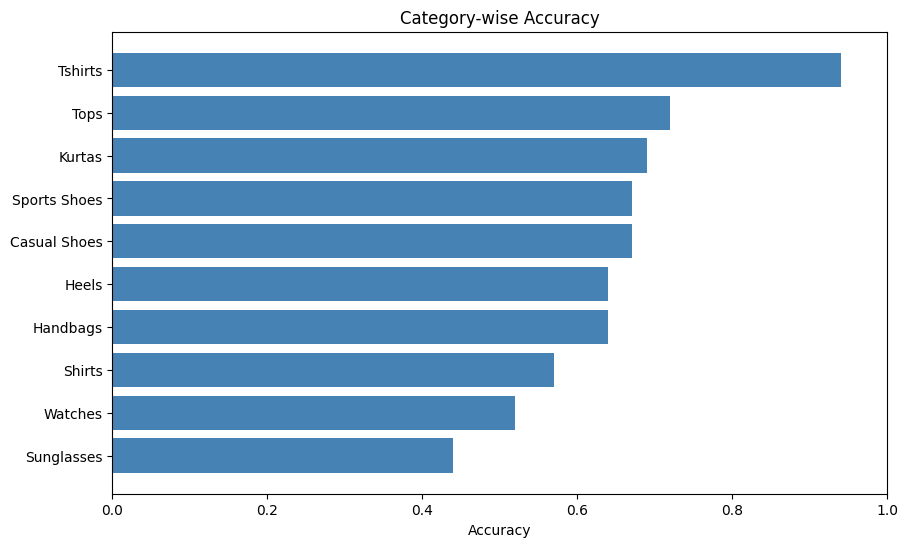

    Category  Accuracy
     Tshirts      0.94
        Tops      0.72
      Kurtas      0.69
Sports Shoes      0.67
Casual Shoes      0.67
       Heels      0.64
    Handbags      0.64
      Shirts      0.57
     Watches      0.52
  Sunglasses      0.44


In [68]:
def category_wise_accuracy(top_n_categories=10):

    results = {}
    top_cats = df_reset['articleType'].value_counts().head(top_n_categories).index.tolist()

    for cat in top_cats:
        cat_ids = df_reset[df_reset['articleType'] == cat]['id'].tolist()
        cat_indices = [i for i, pid in enumerate(valid_ids) if pid in set(cat_ids)]

        if len(cat_indices) < 2:
            continue

        acc = evaluate_fold(cat_indices, image_embeddings, valid_ids, captions_for_training, sample_size=100)
        results[cat] = acc

    result_df = pd.DataFrame(list(results.items()), columns=["Category", "Accuracy"])
    result_df = result_df.sort_values("Accuracy", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(result_df["Category"], result_df["Accuracy"], color="steelblue")
    plt.xlabel("Accuracy")
    plt.title("Category-wise Accuracy")
    plt.xlim(0, 1)
    plt.gca().invert_yaxis()
    plt.show()

    print(result_df.to_string(index=False))

category_wise_accuracy()